In [2]:
id = 'stars'
project_title = 'Tasiyagnunpa Migration 2023'
species_name = 'Tasiyagnunpa'
species_lookup = 'sturnella neglecta'
year = 2023
gbif_filename = 'gbif_tasiyagnunpa.csv'
ecoregions_dir = 'ecoregions'
plot_filename = 'tasiyagnunpa_migration'
plot_height = 500

In [3]:
import os
import pathlib

import earthpy
import geopandas as gpd
import pandas as pd

In [4]:
# Create data directory
project = earthpy.Project(
    'Tasiyagnunpa Migration 2023',
    dirname='migration')
# Download sample data
project.get_data()

# Display the project directory
project.project_dir

PosixPath('/workspaces/data/migration')

<Axes: >

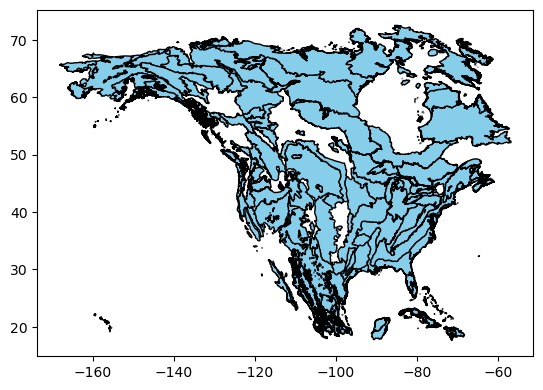

In [5]:
# Open up the ecoregions boundaries
ecoregions_gdf = (
    gpd.read_file(project.project_dir / ecoregions_dir)
)

# Plot the ecoregions quickly to check download
ecoregions_gdf.plot(edgecolor='black', color='skyblue')

In [6]:
gbif_path = project.project_dir / gbif_filename

In [7]:
!head -n 2 $gbif_path 

gbifID	datasetKey	occurrenceID	kingdom	phylum	class	order	family	genus	species	infraspecificEpithet	taxonRank	scientificName	verbatimScientificName	verbatimScientificNameAuthorship	countryCode	locality	stateProvince	occurrenceStatus	individualCount	publishingOrgKey	decimalLatitude	decimalLongitude	coordinateUncertaintyInMeters	coordinatePrecision	elevation	elevationAccuracy	depth	depthAccuracy	eventDate	day	month	year	taxonKey	speciesKey	basisOfRecord	institutionCode	collectionCode	catalogNumber	recordNumber	identifiedBy	dateIdentified	license	rightsHolder	recordedBy	typeStatus	establishmentMeans	lastInterpreted	mediaType	issue
4501319588	2f54cb88-4167-499a-81fb-0a2d02465212	http://arctos.database.museum/guid/DMNS:Bird:57539?seid=6172480	Animalia	Chordata	Aves	Passeriformes	Icteridae	Sturnella	Sturnella neglecta		SPECIES	Sturnella neglecta Audubon, 1844	Sturnella neglecta		US	Fort Collins, 6888 East County Road 56	Colorado	PRESENT		a2ef6dd1-8886-48c9-8025-c62bac973cc7	40.657779	-104.94

In [8]:
# Load the GBIF data
gbif_df = pd.read_csv(
    gbif_path, 
    delimiter='\t',
    index_col='gbifID',
    usecols=['gbifID', 'decimalLatitude', 'decimalLongitude', 'month'])
gbif_df.head()

,decimalLatitude,decimalLongitude,month
gbifID,,,
4501319588,40.657779,-104.949130,5
4501319649,40.266835,-105.163977,7
4697139297,31.569170,-109.700950,2
4735897257,40.582947,-102.277350,4
4719794206,39.266953,-104.515920,6


In [9]:
gbif_gdf = (
    gpd.GeoDataFrame(
        gbif_df, 
        geometry=gpd.points_from_xy(
            gbif_df.decimalLongitude, 
            gbif_df.decimalLatitude), 
        crs="EPSG:4326")
    # Select the desired columns
    [['month', 'geometry']]
)
gbif_gdf

,month,geometry
gbifID,,
4501319588,5,POINT (-104.94913 40.65778)
4501319649,7,POINT (-105.16398 40.26684)
4697139297,2,POINT (-109.70095 31.56917)
4735897257,4,POINT (-102.27735 40.58295)
4719794206,6,POINT (-104.51592 39.26695)
...,...,...
4796460466,4,POINT (-118.89593 35.43725)
4720342585,4,POINT (-109.28928 40.43625)
4725888708,6,POINT (-111.30072 47.66419)


In [10]:
gbif_ecoregion_gdf = (
    ecoregions_gdf
    # Match the CRS of the GBIF data and the ecoregions
    .to_crs(gbif_gdf.crs)
    # Find ecoregion for each observation
    .sjoin(
        gbif_gdf,
        how='inner', 
        predicate='contains')
)
gbif_ecoregion_gdf

,eco_code,area_km2,geometry,gbifID,month
10,NA0520,60755,"POLYGON ((-133.09155 56.16835, -133.08896 56.1...",4741192991,12
20,NA0524,22605,"POLYGON ((-124.11337 49.78677, -124.11584 49.7...",4804940145,10
20,NA0524,22605,"POLYGON ((-124.11337 49.78677, -124.11584 49.7...",4637064851,4
20,NA0524,22605,"POLYGON ((-124.11337 49.78677, -124.11584 49.7...",4729620994,4
20,NA0524,22605,"POLYGON ((-124.11337 49.78677, -124.11584 49.7...",4730353126,4
...,...,...,...,...,...
1995,NA0524,22605,"POLYGON ((-123.58929 48.12869, -123.58399 48.1...",4636938237,1
1995,NA0524,22605,"POLYGON ((-123.58929 48.12869, -123.58399 48.1...",4748206680,5
1995,NA0524,22605,"POLYGON ((-123.58929 48.12869, -123.58399 48.1...",4769937932,1
1995,NA0524,22605,"POLYGON ((-123.58929 48.12869, -123.58399 48.1...",4653802251,2


In [11]:
occurrence_df = (
    gbif_ecoregion_gdf
    # Select only necessary columns
    [['eco_code', 'month', 'gbifID']]
    # For each ecoregion, for each month...
    .groupby(['eco_code', 'month'])
    # ...count the number of occurrences
    .count()
)

# Get rid of rare observation noise (possible misidentification?)
occurrence_df = occurrence_df[occurrence_df.gbifID>3]

# Take the mean by ecoregion
mean_occurrences_by_ecoregion = (
    occurrence_df
    .groupby(['eco_code'])
    .mean()
)
# Take the mean by month
mean_occurrences_by_month = (
    occurrence_df
    .groupby(['month'])
    .mean()
)

In [12]:
occurrence_df['norm_occurrences'] = (
    occurrence_df
    [['gbifID']]
    / mean_occurrences_by_ecoregion
    / mean_occurrences_by_month
)
occurrence_df

gbifID  norm_occurrences
eco_code month                          
Lake     1          22          0.005105
         2          17          0.004242
         3          27          0.005625
         4          22          0.001954
         11          5          0.001219
...                ...               ...
OC0106   7           4          0.000245
         8          10          0.001064
         10         19          0.001925
         11         32          0.003005
         12         80          0.006937

[487 rows x 2 columns]

In [13]:
%store -r ecoregions_gdf occurrence_df

no stored variable or alias ecoregions_gdf
no stored variable or alias occurrence_df


In [14]:
# Get month names
import calendar

# Libraries for Dynamic mapping
import cartopy.crs as ccrs
import hvplot.pandas
import panel as pn

In [15]:
# Simplify the geometry to speed up processing
ecoregions_gdf.geometry = ecoregions_gdf.simplify(.05)

# Change the CRS to Mercator for mapping
ecoregions_gdf = ecoregions_gdf.to_crs(ccrs.Mercator())

# Check that the plot runs
ecoregions_gdf.hvplot(geo=True, crs=ccrs.Mercator())

:Polygons   [Longitude,Latitude]

In [16]:
# Join the occurrences with the plotting GeoDataFrame
occurrence_gdf = ecoregions_gdf.merge(
    occurrence_df.reset_index(), 
    on='eco_code')

# Get the plot bounds so they don't change with the slider
xmin, ymin, xmax, ymax = occurrence_gdf.total_bounds

# Define the slider widget
slider = pn.widgets.DiscreteSlider(
    name='month',
    options={calendar.month_name[i]: i for i in range(1, 13)}
)

# Plot occurrence by ecoregion and month
migration_plot = (
    occurrence_gdf
    .hvplot(
        c='norm_occurrences',
        groupby='month',
        # Use background tiles
        geo=True, crs=ccrs.Mercator(), tiles='CartoLight',
        title=f"{species_name} migration",
        xlim=(xmin, xmax), ylim=(ymin, ymax),
        frame_width=500,
        colorbar=False,
        widgets={'month': slider},
        widget_location='bottom'
    )
)



In [17]:
migration_plot

BokehModel(combine_events=True, render_bundle={'docs_json': {'85c47acc-3462-462b-9b70-77eb9acfdd34': {'version…

In [18]:
# Save the plot (if possible)
try:
    migration_plot.save(f'{plot_filename}.html', embed=True)
except Exception as exc:
    print('Could not save the migration plot due to the following error:')
    print(exc)